# Analiza Rynku Pracy IT w Polsce (2022) - JustJoin.it
Baza danych zawiera oferty pracy na justjoinIT w okresie od  lutego 2022 do liostopada 2022.  
Link do żródła: https://www.kaggle.com/datasets/kriegsmaschine/polish-it-job-board-data-from-2022

Projekt ten stworzyłem w ramach nauki analizy danych oraz chęci weryfikacji moich własnych przekonań odnośnie rynku pracy IT na podstawie 37 tysięcy ogłoszeń z JustJoin.it z roku 2022. Chcę na prawdziwych danych poszukać wskazówek odnośnie tego rynku oraz odpowiedzi na kilka kluczowych pytań.

1) Jakie podejście do juniorów było w roku 2022, czyli w szczycie rynku pracy IT?
2) Czy istnieje sposób na zwiększenie szans na zatrudnienie, kierując się na jakieś szczególne umiejętności?
3) Jak wygląda wejście jako junior na rynek pracy oraz jak wyglądają zarobki w zależności od doświadczenia?
4) Jak wyglądają ścieżki awansu i na czym musi skupić się junior lub mid, by myśleć o awansie?

Wykresy i wnioski, które zaprezentuję, przedstawiają rzetelne dane po dokładnym czyszczeniu i pozbyciu się wszelkich śmieci, które mogłyby zaburzyć prawdziwy obraz przedstawionych danych, jak i końcowe wnioski.
Niektóre wnioski z tej analizy mocno zachwiały moją wiarą w "prawdę z internetu" odnośnie rynku pracy IT jako całości. 

Import niezbędnych bibliotek

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings

Ustawienia globalne  
1/12 mężczyzn jest daltonistą! Jeśli chcesz że by 8% mężczyzn widziało Twoje wykresy dodaj sns.set_palette("colorblind") :)

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x) 
sns.set_palette("colorblind")
sns.set_style("whitegrid")
warnings.filterwarnings('ignore') 

W pliku csv jest przesunięcie danych w kolumnach dlatego należało stworzyć poprawna listę i pominąć nazwy kolumn z pliku csv podczas wczytywania danych. 

In [3]:
real_columns = [
    'Title', 'City', 'Country_code', 'Marker_icon', 'Workplace_type', 
    'Experience_level', 'Published_at', 'Remote_interview', 'Remote', 
    'Open_to_date', 'Company_size_from', 'Company_size_to', 
    'if_permanent', 'salary_from_permanent', 'salary_to_permanent', 'salary_currency_permanent',
    'if_b2b', 'salary_from_b2b', 'salary_to_b2b', 'salary_currency_b2b',
    'if_mandate', 'salary_from_mandate', 'salary_to_mandate', 'salary_currency_mandate',
    'if_other', 'salary_from_other', 'salary_to_other', 'salary_currency_other',
    'currency_exchange_rate', 
    'skill_1', 'skill_val_1', 'skill_2', 'skill_val_2', 'skill_3', 'skill_val_3'
]

df_raw = pd.read_csv('justjoinit.csv', 
                 skiprows=1, 
                 names=real_columns)
df = df_raw.copy()


## Wstępne sprawdzenie danych

<Axes: >

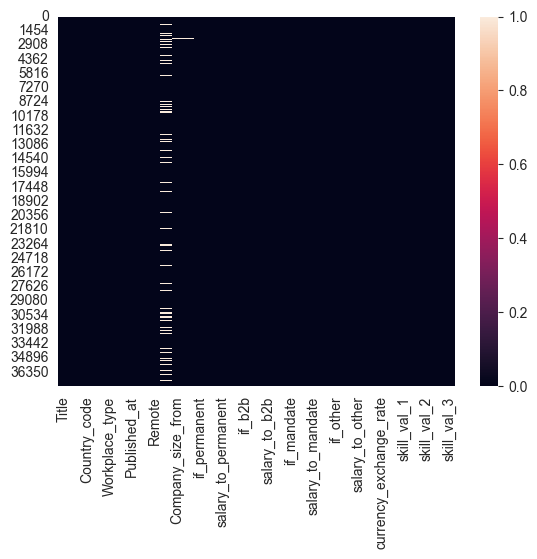

In [4]:
sns.heatmap(df.isnull())

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37787 entries, 0 to 37786
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Title                      37787 non-null  str    
 1   City                       37787 non-null  str    
 2   Country_code               37754 non-null  str    
 3   Marker_icon                37787 non-null  str    
 4   Workplace_type             37787 non-null  str    
 5   Experience_level           37787 non-null  str    
 6   Published_at               37787 non-null  str    
 7   Remote_interview           37787 non-null  bool   
 8   Remote                     37787 non-null  bool   
 9   Open_to_date               32585 non-null  object 
 10  Company_size_from          37732 non-null  str    
 11  Company_size_to            37748 non-null  str    
 12  if_permanent               37787 non-null  bool   
 13  salary_from_permanent      37787 non-null  float64
 14  s

In [6]:
df.describe()

,salary_from_permanent,salary_to_permanent,salary_from_b2b,salary_to_b2b,salary_from_mandate,salary_to_mandate,salary_from_other,salary_to_other,currency_exchange_rate,skill_val_1,skill_val_2,skill_val_3
count,37787.00,37787.00,37787.00,37787.00,37787.00,37787.00,37787.00,37787.00,37787.00,37787.00,37787.00,37787.00
mean,4436.72,6361.92,8533.14,11878.33,113.81,162.44,0.00,0.00,0.01,3.02,3.10,3.10
std,8339.68,11318.56,9433.97,12631.15,1192.99,1700.15,0.00,0.00,0.05,0.94,1.14,1.43
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,3.00,3.00
50%,0.00,0.00,6500.00,10000.00,0.00,0.00,0.00,0.00,0.00,3.00,3.00,3.00
75%,8800.00,13500.00,16000.00,22800.00,0.00,0.00,0.00,0.00,0.00,4.00,4.00,4.00
max,413114.61,495737.53,113246.50,137341.50,39000.00,56808.00,0.00,0.00,0.23,5.00,5.00,5.00


Jak widać baza na pierwszy rzut oka jest w pełni uzupełniona, jednak z tabeli wynika że w wielu miejscach jako wartość wpisane jest 0. Należy to zmienić, tak by późniejsze dane odpowiadał rzeczywistości. 

## Sprzątanie śmieci

Usunięcie zbędnych kolumn, oraz zamiana wartości 0 i unknown na NAN w celu uniknięcia przekłamań danych. Dodatkowo zamiana typu danych na date w kolumnie z datami.

In [7]:
df.drop(['Company_size_to', 'Company_size_from', 'if_mandate', 'salary_from_mandate', 
'salary_to_mandate', 'salary_currency_mandate', 'if_other', 'salary_from_other', 
'salary_to_other', 'salary_currency_other'
],axis=1,inplace=True)

cols_to_fix = ['skill_val_1', 'skill_val_2', 'skill_val_3', 'skill_1', 'skill_2', 'skill_3', 
'salary_to_permanent', 'salary_from_permanent', 'salary_to_b2b', 'salary_from_b2b' ]

df[cols_to_fix] = df[cols_to_fix].replace([0, 'unknown'], np.nan)

df['Published_at'] = pd.to_datetime(df['Published_at']).dt.normalize()

Ustalenie poprawnej kolejności danych w kolumnie Experience_level, ma to kluczowe znaczenie dla czytelności wykresów.

In [8]:
exp_order = ['junior', 'mid', 'senior']
df['Experience_level'] = pd.Categorical(df['Experience_level'], 
                                        categories=exp_order, 
                                        ordered=True)

Dane po sprzątaniu śmieci.

<Axes: >

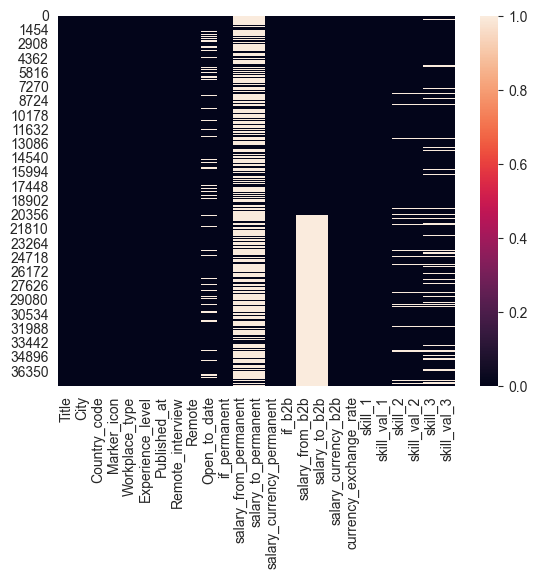

In [9]:
sns.heatmap(df.isnull())

## Analiza danych

Tworzeniu wykresu przedstawiającego % ofert pracy, które zgadzają się na zdalną rozmowę podzielony na wymagany poziom doświadczenia. 

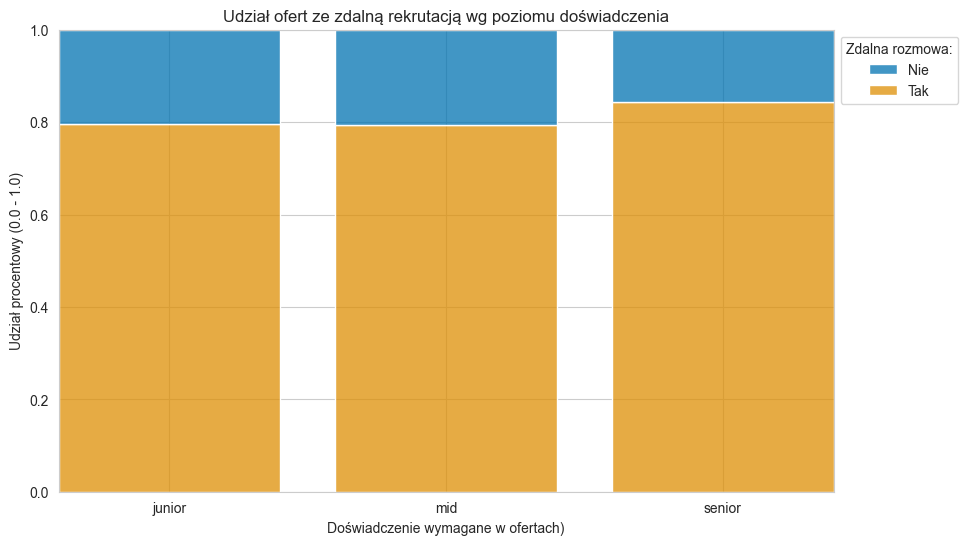

In [10]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(data=df, x='Experience_level', hue='Remote_interview', multiple='fill', shrink=.8)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Zdalna rozmowa:', labels=['Nie', 'Tak'])
plt.ylabel('Udział procentowy (0.0 - 1.0)')
plt.xlabel('Doświadczenie wymagane w ofertach)')
plt.title('Udział ofert ze zdalną rekrutacją wg poziomu doświadczenia')
plt.show()

Już tutaj widzimy pierwszą ciekawostkę. To że firmy w kwesti rekrutacji nie wymagają od seniorów obecności osobistej było do przewidzenia, jednak ciekawe jest to, że w tej kwesti firmy juniorów i midów traktują tak samo. Brak większego zaufania do MID-ów może wiązać się z wymaganiami jakie firmy stawiają przed MID-ami. Ten wątek rozwinę bardziej w dalszej części.

Tworzymy tabele mediany zarobków przewidzianych w ofertach pracy dla każdego poziomu doświadczenia.

In [11]:
salary = df.pivot_table(
    values=['salary_from_permanent', 'salary_to_permanent'], # Bierzemy naszą nową kolunę ujednoliconą
    index='Experience_level', 
    aggfunc=['median',] # Chcemy zobaczyć wszystko na raz!
)
salary

median                    
                 salary_from_permanent salary_to_permanent
Experience_level                                          
junior                         5000.00             8000.00
mid                           10450.00            16000.00
senior                        16000.00            22000.00

Tworzenie 2 połączonych wykresów. Pierwszy zawiera informacje o procentowym udziale ofert podzielonych ze względu na wymagane doświadczenie, natomiast drugi zawiera medianę minimalnych i maksymalnych zarobków pod względem doświadczenia. 

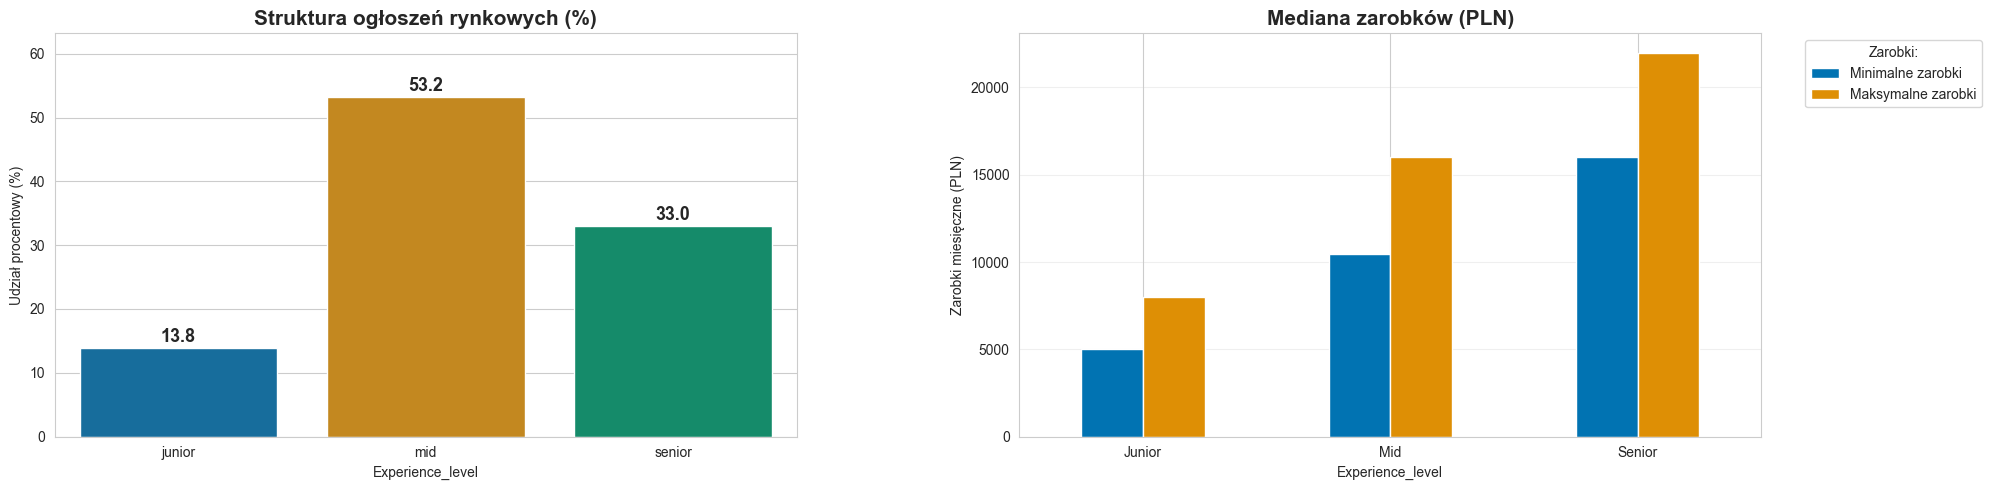

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))


# WYKRES 1
percents = df['Experience_level'].value_counts(normalize=True) * 100
percents = percents.reindex(['junior', 'mid', 'senior'])
sns.barplot(x=percents.index, y=percents.values, hue=percents.index, 
            palette='colorblind', legend=False, ax=axes[0])

for i, v in enumerate(percents.values):
    axes[0].text(i, v + 1, f"{v:.1f}", ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Struktura ogłoszeń rynkowych (%)', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Udział procentowy (%)')
axes[0].set_ylim(0, percents.max() + 10)

# WYKRES 2
salary['median'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Mediana zarobków (PLN)', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Zarobki miesięczne (PLN)')
axes[1].set_xticklabels(['Junior', 'Mid', 'Senior'], rotation=0)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Zarobki:', labels=['Minimalne zarobki', 'Maksymalne zarobki'])
axes[1].grid(axis='y', alpha=0.3)
# --- WYKOŃCZENIE ---
plt.tight_layout()
plt.subplots_adjust(wspace=0.30) 
plt.show()

Z tych wykresów można wywnioskować kilka rzeczy. Pracodawcy najbardziej chcą mid-ów, prawdopodobnie dlatego że nie muszą ich szkolić, jednocześnie nie muszą im dużo płacić. Duży procentowy udział ogłoszeń na mid-a, może świadczyć również o tym, że jest to w dużej mierze "myślenie życzeniowe" firm, które ewidentnie potrzebują rąk do pracy, jednocześnie mają nadzieje że "midzi rosną na drzewach" i prędzej czy później się pojawią. W dłuższej perspektywie takie podejście musi się skończyć, dlatego nawet będąc juniorem warto aplikować na stanowiska mid-a, bo w pewnym momencie firmy z braku mid-ów na rynku mogą zostać zmuszone do zmniejszenia wymagań. Nie zmienia to jednak faktu że z powodu znikomej liczby ofert pracy na najniższe stanowiska poziom "wejścia" dla juniora jest dość wysoki.  

Definiuje funkcję poprawiającą czytelność wykresów która grupuje wymagany poziom zaawansowania w danej umiejętności na 3 grupy zamiast 5.

In [13]:
def group_skill_v2(val):
    if pd.isna(val): return np.nan # Jeśli brak danych, zostawiamy jako NaN
    if val <= 2: return '1-2 (Podstawowy)'
    elif val == 3: return '3 (Średni)'
    else: return '4-5 (Zaawansowany)'

Tworze kolumny pomocnicze.

In [14]:
df['skill_1_group'] = df['skill_val_1'].apply(group_skill_v2)
df['skill_2_group'] = df['skill_val_2'].apply(group_skill_v2)
df['skill_3_group'] = df['skill_val_3'].apply(group_skill_v2)
skills_order = ['1-2 (Podstawowy)', '3 (Średni)', '4-5 (Zaawansowany)']

Zmiana formatu tabeli z "szerokiego" na "długi" (Long Format). Czyli Utworzenie nowej df w której dla każdego ogłoszenia powstają 3 wiersze danych, zawierające konkretny nr skila wymaganego przez pracodawce. Dzięki temu uda się przedstawić te dane na 1 dużym wykresie.

In [15]:
df_skills_long = df.melt(id_vars=['Experience_level'], 
                         value_vars=['skill_1_group', 'skill_2_group', 'skill_3_group'],
                         var_name='Skill_Number', 
                         value_name='Skill_Intensity')

Tworzenie rozbudowanego wykresu zawierajacego zestawienie 3 kluczowych umiejętności dla każdego poziomu doświadczenia.

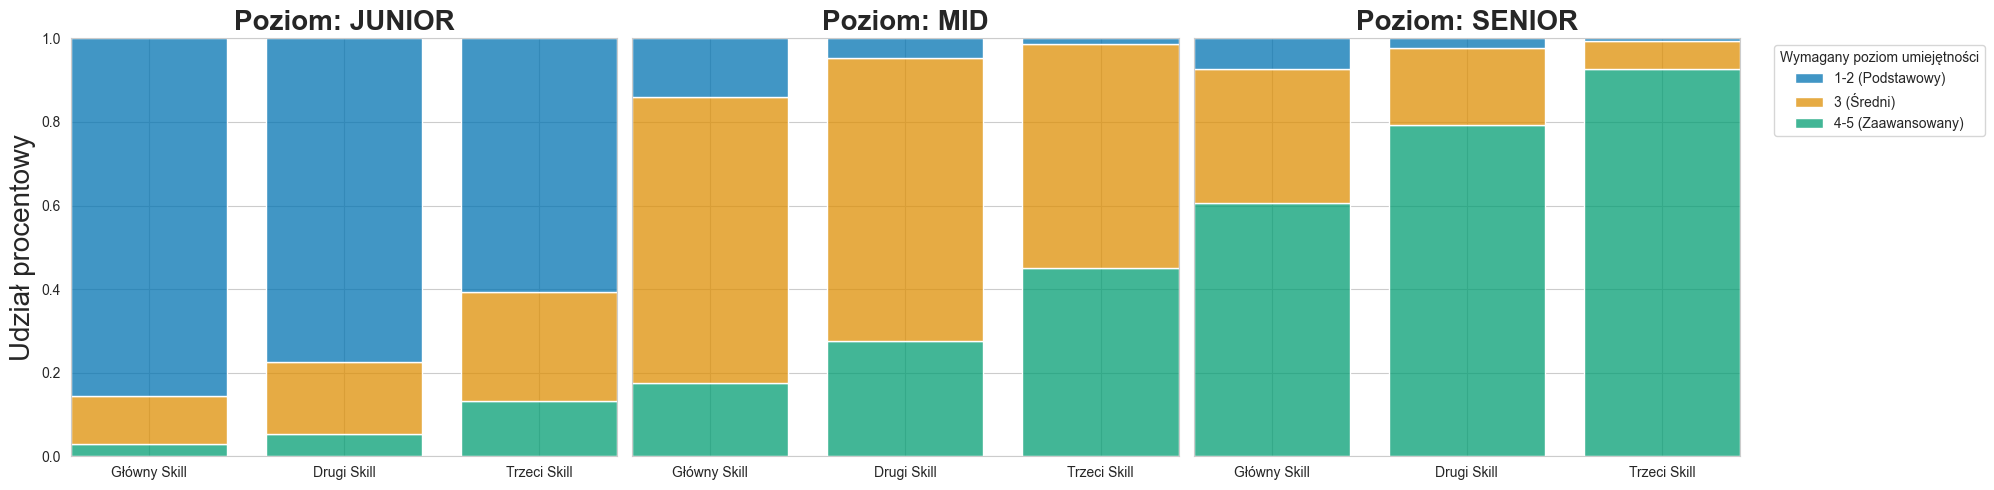

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
exp_levels = ['junior', 'mid', 'senior']
for i, level in enumerate(exp_levels):

    subset = df_skills_long[df_skills_long['Experience_level'] == level]
    
    sns.histplot(data=subset, x='Skill_Number', hue='Skill_Intensity', 
                 hue_order=skills_order, multiple='fill', shrink=.8, 
                 ax=axes[i], palette='colorblind')
    
    axes[i].set_xticks([0, 1, 2])
    axes[i].set_xticklabels(['Główny Skill', 'Drugi Skill', 'Trzeci Skill'])
    
    axes[i].set_title(f'Poziom: {level.upper()}', fontsize=20, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Udział procentowy', fontsize=20,)
    
    if i < 2:
        axes[i].get_legend().remove()
    else:
        sns.move_legend(axes[i], "upper left", bbox_to_anchor=(1.05, 1), title="Wymagany poziom umiejętności")
plt.tight_layout()
plt.show()

Wykres ten przedstawia procentowy podział wymagań jakie pracodawcy stawiają przed pracownikami. Wykresy pokazuja kilka ciekawostek. Pierwszą z nich jest fakt że głowna zdolność na wszystkich stanowiskach jest najmniej istotna w procesie rekrutacji, to dodatkowe umiejętności lub specjalizacje dają największe atuty podczas rekrutacji. Świadczy to o tym że pracodawca liczy się z koniecznościa szkolenia pracownika w jego głownej dziedzinie, jednak oczekuje że drugorzędne umiejętności pracownik ma opanowane. Można powiedzieć że pracodawca woli by pracownik nauczył się składni innego języka, ale znał sql, niż żeby musaił uczyć kogoś obeznanego np z pythonem baz danych. Dodatkowa informacja płynąca z wykresu to fakt że przy połączeniu średniego i zaawansowanego poziomu umiejętności, wymagania dla mida i seniora są praktycznie identyczne. Mówiąć obrazowo firmy uważają że mid powinien robić to samo co senior, tylko wolniej. Warty zauważenia jest fakt że pomimo liniowego wzrostu wynagrodzeń między juniorem a mid-em jest drastyczny wzrost wymagań. Z jednej strony jest to dobre, ponieważ juniorzy mimo braku doświadczenia mogą liczyć na sensowne zarobki, jednocześnie może oznaczać że awans w strukturach firmy wymaga dużego nakładu pracy i nauki. Kolejną dobrą wiadomością jest to że zapotrzebowanie na mid-ów wpływa na chęć pracodawcy w inwestowanie w swoich najmłodszych stażem pracowników. Daje to możliwość rozwoju bo to pracodawcy zależy na wykwalifikowanym pracowniku. Wąskim gardłem jest jednak dostanie się na juniora, jeśli to się uda, kariera w IT stoi otworem. 

Tworze wykres zawierający dane o częstotliwości wymagań odnośnie poziomu zaawansowania w danej umiejętności.

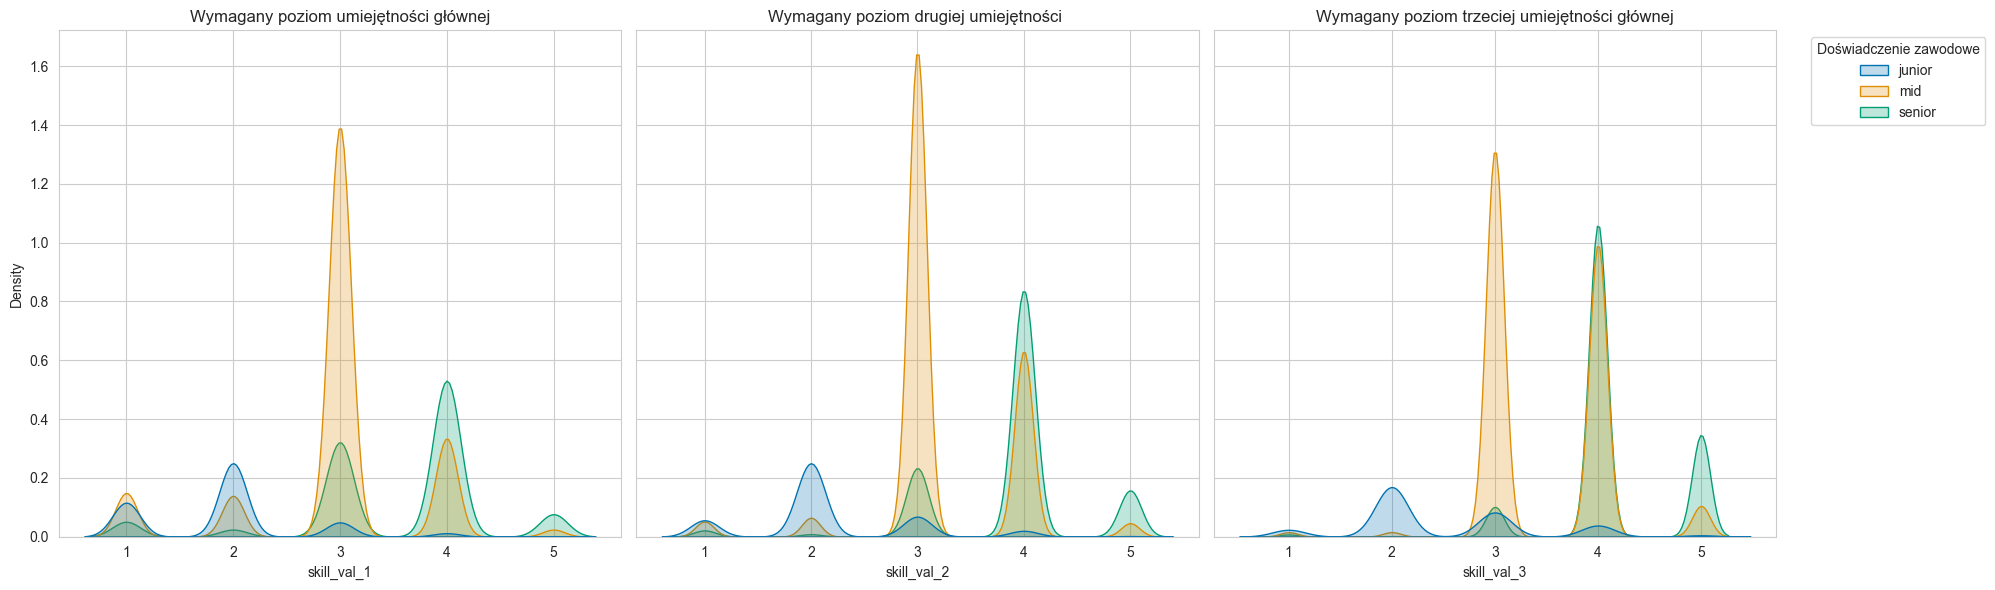

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

sns.kdeplot(data=df, x='skill_val_1', hue='Experience_level', fill=True, ax=axes[0])
axes[0].set_title('Wymagany poziom umiejętności głównej')
axes[0].get_legend().remove()

sns.kdeplot(data=df, x='skill_val_2', hue='Experience_level', fill=True, ax=axes[1])
axes[1].set_title('Wymagany poziom drugiej umiejętności ')
axes[1].get_legend().remove()

sns.kdeplot(data=df, x='skill_val_3', hue='Experience_level', fill=True, ax=axes[2])
axes[2].set_title('Wymagany poziom trzeciej umiejętności głównej')
sns.move_legend(axes[2], "upper left", bbox_to_anchor=(1.05, 1), title="Doświadczenie zawodowe")


plt.tight_layout() 
plt.show()


Mamy tu wykres przedstawiajacy wymagania poziomu umiejetnosci w zależności od poziomu doświadczenia. W oczy rzuca się kilka rzeczy. Po pierwsze od junioirów we wszystkich 3 kluczowych dla stanowiska umiejetnosciach, wymaga się zdolności na poziomie 2 co pokazuje że w oczach pracodawcy junior to nie osoba wchodząca na rynek pracy lecz ktoś kto posiadł już jakieś umiejętności wykraczajace poza kursy czy samą naukę. Najciekawsze jednak są dane o ofertach na "Mida", przedstawiają one że w oczach pracodawcy "mid" to osoba które wszystkie 3 głowna umiejętność opanowała przynajmniej na poziomie średniozaawansowanym, co jednak jeszcze ciekawsze, pracodawcy wymagają wiedzy w kluczowych dziedzinach na poziomie 4 z praktycznie taką samą częstotliwością dla mida i seniora. Różnica między midem a seniorem jest taka że od seniora trzykrotnie częściej wymaga się umiejętności na poziomie 5. Podsumowująć junior w oczach pracodawcy to osoba z doświadczeniem a od której wymaga się umiejętności wykraczających poza ramy nauki, od mida wymaga niewiele mniej niż od seniora, a głowna różnica polega na specjalizacji seniora w jednej lub dwuch konkretych dziedzinach.

# Podsumowanie

W 2022 roku mimo szczytu zapotrzebowania na programistów firmy nie chciały szkolić "od zera" nawet od juniorów wymagano wiedzy wykraczającej poza ramy standardowych kursów czy nauki. Dane wskazują że kluczem do zwiększenia szansy na zatrudnienie, a później na awans jest specjalizacja w wąskiej dziedzinie w jak największym stopniu. Pracodawcy wolą zapłacić za eksperta w jednej dziedzinie niż za przyzwoitego we wszystkim. Juniorowi ciężko jest wejść na rynek i znaleźć pierwszą pracę, jednak fakt dużej ilości ofert na mid-a musi w pewnym momencie spowodować albo wzrost ofert juniorów, albo spadek wymagań na mid-a, dlatego tym bardziej specjalizacja w wąskiej dziedzinie może przynieść zdecydowanie większe korzyści niż nauka ogólna. Osoba chcąca dostać prace w rynku IT powinna skupić się nie na umiejętnościach ogólnych jak język programowania lecz powinna od początku postawić na konkretną umiejętność i doprowadzić ją do poziomu "3", takie podejście powinno otworzyć wiele stanowisk mida nawet bez większego doświadczenia. 